In [4]:
# 1. SciBert - (pritamdeka/S-Scibert-snli-multinli-stsb)
# 2. BioBERT- (emilyalsentzer/Bio_ClinicalBERT)
# 3. Transformer model (all-MiniLM-L6-v2)
# 4. RoBERTa (sentence-transformers/all-roberta-large-v1)

# !pip install huggingface_hub[hf_xet] -q
# !pip install hf_xet -q

# !pip install --upgrade torch>=2.6.0 -q

# Uninstall current version
!pip uninstall torch torchvision torchaudio -y -q

# Install PyTorch 2.8.0 (stable version without the DLL issue)
!pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cpu -q

import torch
print(torch.__version__)
# # 2.2.1+cpu


[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2.10.0+cpu


In [5]:
import pandas as pd
import numpy as np

from skimage.feature import graycomatrix, graycoprops

from sentence_transformers import SentenceTransformer, util
# import torch

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'PreTrainedModel' from 'transformers' (C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\transformers\__init__.py)

In [ ]:
SentenceTransformer_model = SentenceTransformer('pritamdeka/S-Scibert-snli-multinli-stsb', trust_remote_code=True)

seen_class_labels = ['Atelectasis', 'Consolidation', 'Effusion', 'Hernia', 'Mass', 'No Finding', 'Pneumonia']
seen_idx_to_class = {k: v for k, v in enumerate(seen_class_labels)}
seen_words = list(seen_idx_to_class.values()) 
seen_embeddings = SentenceTransformer_model.encode(seen_words, convert_to_tensor=True)

unseen_class_labels = ['Cardiomegaly', 'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Nodule', 'Pleural_Thickening', 'Pneumothorax']
unseen_idx_to_class = {k: v for k, v in enumerate(unseen_class_labels)}
unseen_words = list(unseen_idx_to_class.values()) 
unseen_embeddings = SentenceTransformer_model.encode(unseen_words, convert_to_tensor=True)

In [ ]:
Data_Entry = pd.read_csv('Data_Entry_2017.csv')
Data_Entry = Data_Entry[['Image Index' , 'Finding Labels']]
Data_Entry.head()

In [ ]:
result = pd.read_csv('resnet50_result_classification report without transformer_unseen.csv')
result.head()

In [ ]:
def get_top_similar_classes_df(predicted_class, sentence_model, class_embeddings, class_labels, k=5):
    """
    Get top k similar classes and return them as a tuple of lists
    """
    # Encode the predicted class
    unseen_query = sentence_model.encode(predicted_class, convert_to_tensor=True)
    
    # Calculate cosine similarities
    unseen_cosine_scores = util.cos_sim(unseen_query, class_embeddings)
    unseen_top_results = torch.topk(unseen_cosine_scores[0], k=k)
    
    # Extract top class names and probabilities
    top_class_names = []
    top_probabilities = []
    for score, idx in zip(unseen_top_results.values, unseen_top_results.indices):
        top_class_names.append(class_labels[idx])
        top_probabilities.append(float(f"{score:.2f}"))
    
    return top_class_names, top_probabilities

# Apply to DataFrame and expand into two columns
result['top_class_names'], result['top_probabilities'] = zip(*result['pred_image_label'].apply(
    lambda x: get_top_similar_classes_df(x, SentenceTransformer_model, unseen_embeddings, unseen_class_labels)
))

# View the results
display(result[['image_label', 'pred_image_label', 'top_class_names', 'top_probabilities']].head())

In [ ]:
# if predicted_class != 'No Finding':
#     seen_query = SentenceTransformer_model.encode(predicted_class, convert_to_tensor=True)
#     seen_cosine_scores = util.cos_sim(seen_query, seen_embeddings)
#     seen_top_results = torch.topk(seen_cosine_scores[0], k=5)
#     seen_class_names, seen_probabilities = [], []
#     for score, idx in zip(seen_top_results.values, seen_top_results.indices):
#         seen_class_names.append(seen_class_labels[idx])
#         seen_probabilities.append(float(f"{score:.2f}"))
        
#     unseen_query = SentenceTransformer_model.encode(predicted_class, convert_to_tensor=True)
#     unseen_cosine_scores = util.cos_sim(unseen_query, unseen_embeddings)
#     unseen_top_results = torch.topk(unseen_cosine_scores[0], k=5)
#     unseen_class_names, unseen_probabilities = [], []
#     for score, idx in zip(unseen_top_results.values, unseen_top_results.indices):
#         unseen_class_names.append(unseen_class_labels[idx])
#         unseen_probabilities.append(float(f"{score:.2f}"))
#     seen_data = pd.DataFrame({'Class': seen_class_names, 'Probability': seen_probabilities})
#     unseen_data = pd.DataFrame({'Class': unseen_class_names, 'Probability': unseen_probabilities})

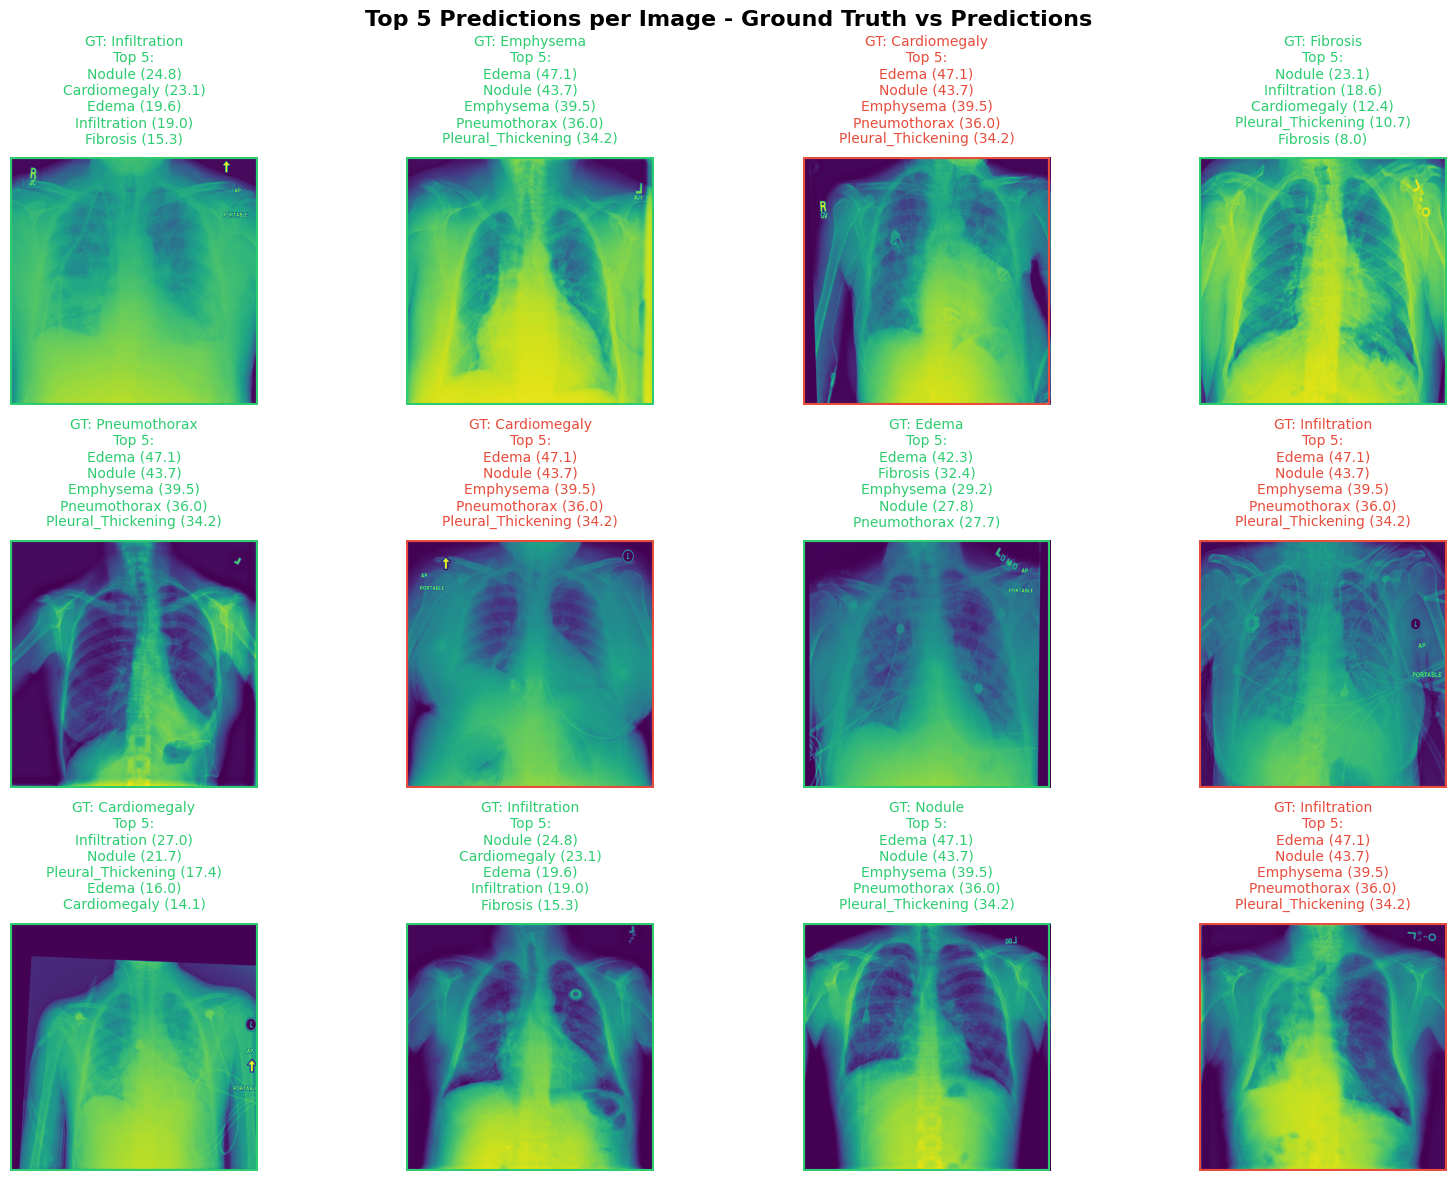


SUMMARY STATISTICS
Total images analyzed: 8000
Ground truth in Top 1 predictions: 1041 (13.0%)
Ground truth in Top 3 predictions: 2912 (36.4%)
Ground truth in Top 5 predictions: 5077 (63.5%)

------------------------------------------------------------
PER-CLASS STATISTICS
------------------------------------------------------------
Edema               : 928/1000 (92.8%)
Nodule              : 867/1000 (86.7%)
Fibrosis            : 624/1000 (62.4%)
Pleural_Thickening  : 652/1000 (65.2%)
Pneumothorax        : 506/1000 (50.6%)
Infiltration        : 488/1000 (48.8%)
Cardiomegaly        : 498/1000 (49.8%)
Emphysema           : 514/1000 (51.4%)

POSITION ANALYSIS
Average rank of correct prediction: 3.1
Median rank: 3.0

Rank distribution:
  Rank 1: 1041 images (20.5%)
  Rank 2: 852 images (16.8%)
  Rank 3: 1019 images (20.1%)
  Rank 4: 1104 images (21.7%)
  Rank 5: 1061 images (20.9%)


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random
import numpy as np
from matplotlib.patches import Rectangle
import ast

# Load the CSV file
df = pd.read_csv('resnet50_result_classification report with transformer_unseen.csv')

# Function to safely parse the similar_wds column
def parse_similar_wds(s):
    try:
        # Convert string representation to tuple
        if isinstance(s, str):
            parsed = ast.literal_eval(s)
            if isinstance(parsed, tuple) and len(parsed) == 2:
                return parsed
    except:
        pass
    return None

# Parse similar_wds column
df['similar_wds_parsed'] = df['similar_wds'].apply(parse_similar_wds)
df['top_predictions'] = df['similar_wds_parsed'].apply(lambda x: x[0] if x is not None else [])
df['prediction_scores'] = df['similar_wds_parsed'].apply(lambda x: x[1] if x is not None else [])

# Filter out rows where parsing failed
df = df[df['top_predictions'].apply(lambda x: len(x) > 0)].reset_index(drop=True)

# Randomly select 12 images (3x4 grid)
random.seed(42)  # For reproducibility
selected_images = df.sample(n=12, random_state=40)

# Create figure with subplots
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Top 5 Predictions per Image - Ground Truth vs Predictions', fontsize=16, fontweight='bold')

# Color definitions
GREEN = '#2ecc71'
ORANGE = '#f39c12'
RED = '#e74c3c'

# Process each image
for idx, (ax, (_, row)) in enumerate(zip(axes.flat, selected_images.iterrows())):
    # Get image path and try to load image
    img_path = row['image_path'][1:]
    ground_truth = row['image_label']
    top_preds = row['top_predictions'][:6]  # Get top 3 predictions
    pred_scores = row['prediction_scores'][:6] if len(row['prediction_scores']) >= 3 else []
    
    # Determine color for ground truth
    if ground_truth in top_preds:
        color = GREEN  # True positive - label is in top predictions
    else:
        color = RED  # False negative - label not in top predictions
    
    # Try to load and display image
    try:
        # Load image (you may need to adjust the base path if images are not in current directory)
        # The path might need to be adjusted based on your local setup
        img = Image.open(img_path)
        ax.imshow(img)
    except Exception as e:
        # If image can't be loaded, show placeholder
        ax.text(0.5, 0.5, 'Image not found\n' + str(e)[:50], 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    
    ax.axis('off')
    
    # Add colored frame around the image
    rect = Rectangle((0, 0), 1, 1, transform=ax.transAxes, 
                     linewidth=3, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    
    # Add title with ground truth and predictions
    pred_text = '\n'.join([f"{pred} ({score:.1f})" for pred, score in zip(top_preds, pred_scores)])
    ax.set_title(f'GT: {ground_truth}\nTop 5:\n{pred_text}', 
                 fontsize=10, pad=10, color=color)

# # Add legend
# legend_elements = [
#     plt.Rectangle((0, 0), 1, 1, facecolor=GREEN, alpha=0.7, label='True Positive (GT in top 5)'),
#     plt.Rectangle((0, 0), 1, 1, facecolor=ORANGE, alpha=0.7, label='False Negative (GT not in top 5)'),
#     plt.Rectangle((0, 0), 1, 1, facecolor=RED, alpha=0.7, label='False Positive (shown in predictions)')
# ]

# fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, 
#            bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

total = len(df)
gt_in_top1 = sum(df.apply(lambda x: x['image_label'] in x['top_predictions'][:1], axis=1))
gt_in_top3 = sum(df.apply(lambda x: x['image_label'] in x['top_predictions'][:3], axis=1))
gt_in_top5 = sum(df.apply(lambda x: x['image_label'] in x['top_predictions'][:5], axis=1))

print(f"Total images analyzed: {total}")
print(f"Ground truth in Top 1 predictions: {gt_in_top1} ({gt_in_top1/total*100:.1f}%)")
print(f"Ground truth in Top 3 predictions: {gt_in_top3} ({gt_in_top3/total*100:.1f}%)")
print(f"Ground truth in Top 5 predictions: {gt_in_top5} ({gt_in_top5/total*100:.1f}%)")

# Per-class statistics
print("\n" + "-"*60)
print("PER-CLASS STATISTICS")
print("-"*60)

for class_name in df['image_label'].unique():
    class_df = df[df['image_label'] == class_name]
    class_total = len(class_df)
    class_in_top3 = sum(class_df.apply(lambda x: class_name in x['top_predictions'][:6], axis=1))
    print(f"{class_name:20s}: {class_in_top3}/{class_total} ({class_in_top3/class_total*100:.1f}%)")

# Show examples of different cases
# print("\n" + "="*60)
# print("EXAMPLE CASES")
# print("="*60)

# Example of True Positive (GT in top predictions)
tp_example = df[df.apply(lambda x: x['image_label'] in x['top_predictions'][:6], axis=1)].iloc[0]
# print(f"\n✓ TRUE POSITIVE - {tp_example['image_label']}")
# print(f"  Image: {tp_example['image_path']}")
# print(f"  Top predictions: {tp_example['top_predictions'][:3]}")
# print(f"  Scores: {[f'{s:.1f}' for s in tp_example['prediction_scores'][:3]]}")

# Example of False Negative (GT not in top predictions)
fn_example = df[~df.apply(lambda x: x['image_label'] in x['top_predictions'][:3], axis=1)].iloc[0]
# print(f"\n✗ FALSE NEGATIVE - {fn_example['image_label']}")
# print(f"  Image: {fn_example['image_path']}")
# print(f"  Top predictions: {fn_example['top_predictions'][:3]}")
# print(f"  Scores: {[f'{s:.1f}' for s in fn_example['prediction_scores'][:3]]}")

# Example where ground truth appears at different positions
print("\n" + "="*60)
print("POSITION ANALYSIS")
print("="*60)

positions = []
for _, row in df.iterrows():
    if row['image_label'] in row['top_predictions']:
        pos = row['top_predictions'].index(row['image_label']) + 1
        positions.append(pos)

if positions:
    print(f"Average rank of correct prediction: {np.mean(positions):.1f}")
    print(f"Median rank: {np.median(positions):.1f}")
    print("\nRank distribution:")
    for rank in range(1, 6):
        count = positions.count(rank)
        print(f"  Rank {rank}: {count} images ({count/len(positions)*100:.1f}%)")